In [3]:
import numpy as np
import os
# sys
import matplotlib.pyplot as plt
# import argparse
import pandas as pd
import nibabel as nib
# import nilearn as nil
# import seaborn as sns
import statsmodels.stats.multitest as smm

In [4]:
#importing the data from the csv file in the folder second_level_results
os.environ["ROOTDIR"] = r'C:\Users\angel\Documents\INPD_neuroimages_CAPE'  # seth path

workdir = os.environ["ROOTDIR"]
secondlvresults  = os.path.join(workdir,"second_level_results")

# shaeffer_network = pd.read_csv('tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv', delimiter='\t')
# #extract the index with the name with SalVentAttn - salience network
# salience_index = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn')]
# #extract the index with the name with Default - default mode network
# default_index = shaeffer_network[shaeffer_network['name'].str.contains('Default')]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

# setting the seed name and the rois which had results in the second level analysis
seed = 'DRPutamen'
rois_tot = [42, 43, 44, 46, 98, 99]
rois_pa = [44, 94, 98]

#stat a dictionary to store the salience and default values
results = {}
tmap = {}

for cape in ['cape_PA_score', 'cape_tot']:

    # loading cape PA score results
    if cape == 'cape_PA_score':
        results[cape] = {}
        for roi in rois_pa:
            results[cape][roi] = pd.read_csv(os.path.join(secondlvresults,f'{cape}-{seed}-roi_{roi}_2ndlvl.csv'), index_col=0)
    
    # loading cape tot results
    elif cape == 'cape_tot':
        results[cape] = {}
        for roi in rois_tot:
            results[cape][roi] = pd.read_csv(os.path.join(secondlvresults,f'{cape}-{seed}-roi_{roi}_2ndlvl.csv'), index_col=0)

for seed in seednames:
    # loading the tmap results  
    tmap[f'{seed}'] = pd.read_csv(os.path.join(secondlvresults,f"{seed}_data-2ndlvl.csv"), index_col=0, header=0)


## Cape total results

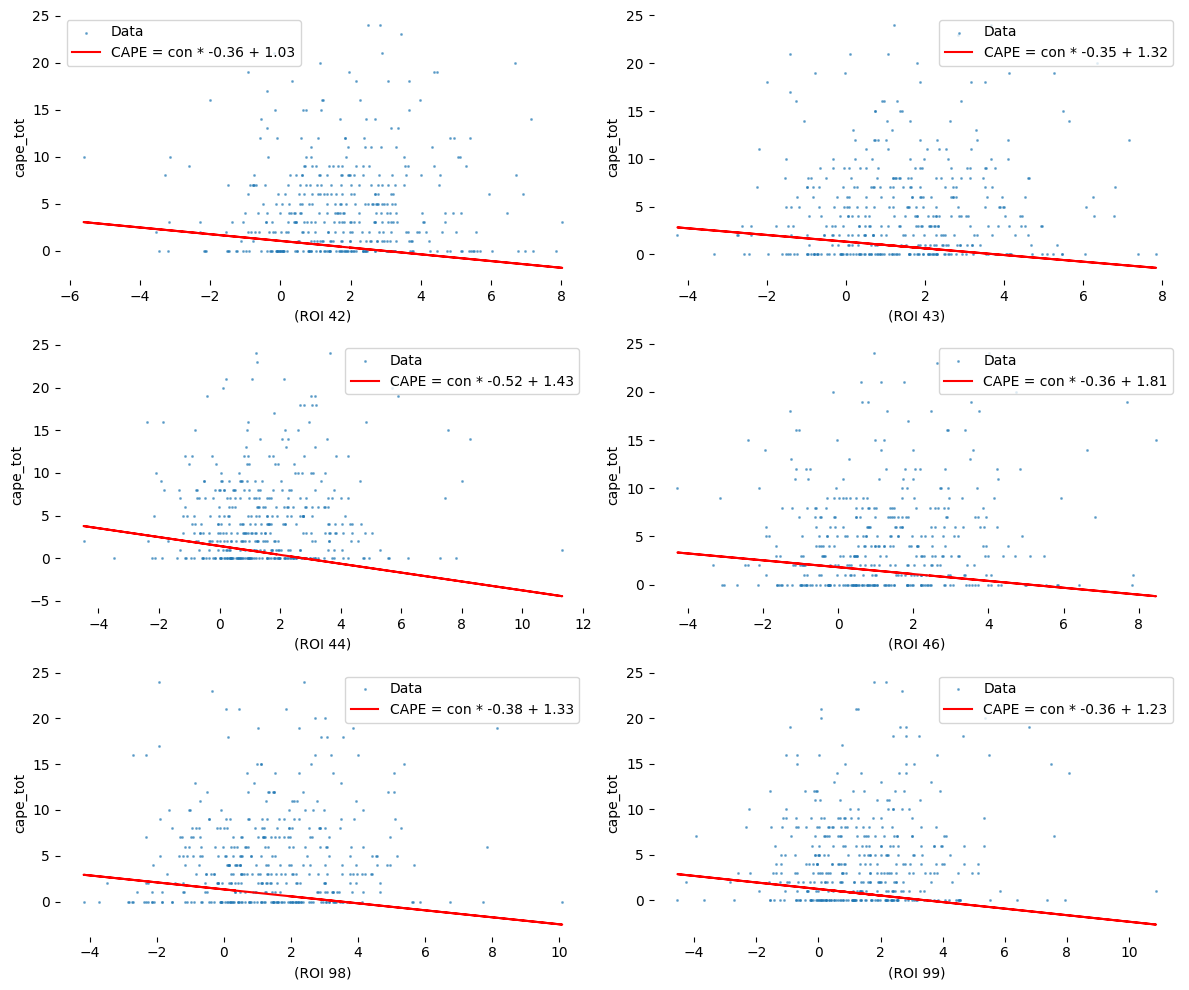

In [57]:
plt.figure(figsize=(30/2.5 , 25/2.5)) 

#plotting for CAPE total
cape = 'cape_tot'
seed = 'DCPutamen'
var_dep = tmap[f'{seed}'][f'{cape}'] # dependent variable (CAPE score)


for ind, roi in enumerate(rois_tot): 
    var_ind = tmap[f'{seed}'][f'roi_{roi}'] # independent variable (ROI connectivity)   

    plt.subplot(3 , 2, ind+1)
    # Scatter plot of ROI connectivity and CAPE Total
    plt.scatter(
        var_ind, 
        var_dep, 
        label='Data',
        s=5,
        marker='.',
        alpha=0.5,
    )

    # Plot regression line
    plt.plot(
        var_ind, 
        var_ind* results[f'{cape}'][roi]['coef'].values[0] + results[f'{cape}'][roi]['intercept'].values[0],
        color='red', 
        label=f'CAPE = con * {results[f'{cape}'][roi]['coef'].values[0]:.2f} + {results[f'{cape}'][roi]['intercept'].values[0]:.2f}'
    )

    # Add labels, title, and legend
    # plt.ylim(-1,25)
    plt.xlabel(f'(ROI {roi})')
    plt.ylabel(f'{cape}')
    plt.legend()

    ax = plt.gca()  # Get the current axis
    ax.spines['top'].set_visible(False)  # Hide the top spine
    ax.spines['right'].set_visible(False)  # Hide the right spine
    ax.spines['left'].set_visible(False)  # Hide the left spine
    ax.spines['bottom'].set_visible(False)  # Hide the bottom spine

        
    # Remove axis and contour lines
    # plt.axis('off')  # Turn off the axis
    ax = plt.gca()  # Get the current axis
    ax.spines['top'].set_visible(False)  # Hide the top spine
    ax.spines['right'].set_visible(False)  # Hide the right spine
    ax.spines['left'].set_visible(False)  # Hide the left spine
    ax.spines['bottom'].set_visible(False)  # Hide the bottom spine
    # ax.lines[0].set_visible(False)  # Hide the first line (scatter plot)
    # ax.xaxis.set_ticks([])  # Hide x-axis ticks
    # ax.yaxis.set_ticks([])  # Hide y-axis ticks
    plt.tight_layout()

# Show the plot
plt.show()

In [5]:
#create plots witt the t maps of the salience and default values in the brain
from templateflow.api import get
from nilearn.plotting import plot_roi, plot_anat    

atlas_name = 'Schaefer2018'
desc_name = '100Parcels7Networks'


atlas_file = get('MNI152NLin2009cAsym',
resolution=2,
atlas= atlas_name,
desc= desc_name
)
# Load the atlas using nibabel
atlas = nib.load(atlas_file)

# Step 1: create zero image
masks = np.zeros(np.shape(atlas), dtype=np.float32)

# Step 2: Use the affine matrix from the atlas
affine = atlas.affine

atlas_data = atlas.get_fdata()  # Use get_fdata() instead of get_data()

for roi_id in rois_tot:

    # Step 3: Find the indices where the atlas has the ROI ID
    ix = np.where(atlas_data == roi_id)  # ROI ID in atlas

    t_value = results[f'{cape}'][roi_id]['t_value']
    if isinstance(t_value, pd.Series):  # If it's a Series, extract the first value
        t_value = t_value.iloc[0]
    t_value = float(t_value)  # Ensure it is a float

    # 4. Assign the t-value to the corresponding voxels in the mask
    masks[ix] = t_value

# Step 5: Create a NIfTI image using the modified zero_volume
tmap_affined = nib.Nifti1Image(masks, affine)

# Step 6: Plot the tmap in the brain
fig, ax = plt.subplots(figsize=(30/2.5, 10/2.5))  # Create a Matplotlib figure
display = plot_roi(
    tmap_affined,
    display_mode='mosaic',
    colorbar=True,
    vmin=-4,
    vmax=-2.5,
    cmap='cool_r',  # Color map for the t-map
    figure=fig  # Pass the Matplotlib figure
)

# Step 7: Customize the color bar
cbar = plt.gcf().get_axes()[-1]  # Get the color bar axis (last axis in the figure)
cbar.set_yticks([-4, -3.5, -3, -2.5])  # Set custom tick values
cbar.set_yticklabels(['-4.0', '-3.5', '-3.0', '-2.5'])  # Set custom tick labels

ax.spines['top'].set_visible(False)  # Hide the top spine
ax.spines['right'].set_visible(False)  # Hide the right spine
ax.spines['left'].set_visible(False)  # Hide the left spine
ax.spines['bottom'].set_visible(False)  # Hide the bottom spine
ax.xaxis.set_ticks([])  # Hide x-axis ticks
ax.yaxis.set_ticks([])  # Hide y-axis ticks

# Show the plot
plt.show()

ModuleNotFoundError: No module named 'templateflow'

## Cape PA

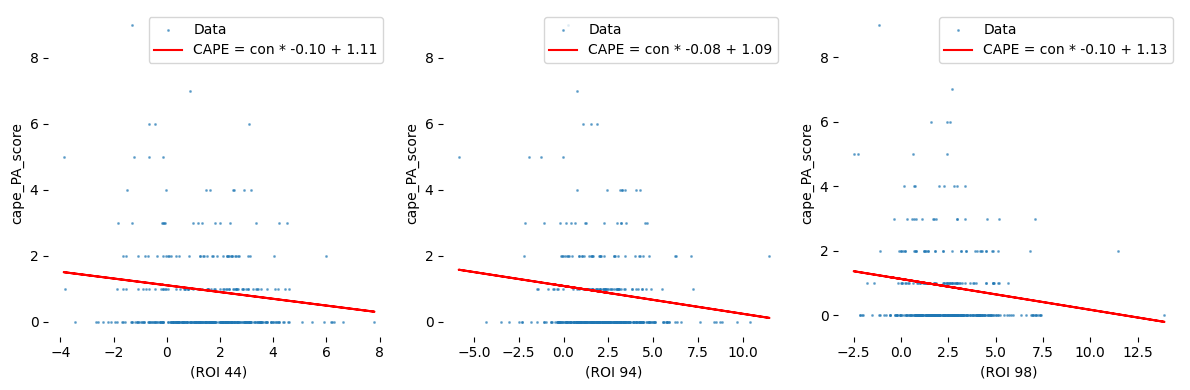

In [43]:
plt.figure(figsize=(30/2.5 , 10/2.5)) 

#plotting for CAPE total
cape = 'cape_PA_score'
seed = 'DRPutamen'
var_dep = tmap[f'{seed}'][f'{cape}'] # dependent variable (CAPE score)

for ind, roi in enumerate(rois_pa): 
    var_ind = tmap[f'{seed}'][f'roi_{roi}'] # independent variable (ROI connectivity)   

    plt.subplot(1 , 3, ind+1)
    # Scatter plot of ROI connectivity and CAPE Total
    plt.scatter(
        var_ind, 
        var_dep, 
        label='Data',
        s=5,
        marker='.',
        alpha=0.5,
    )

    # Plot regression line
    plt.plot(
        var_ind, 
        var_ind * results[f'{cape}'][roi]['coef'].values[0] + results[f'{cape}'][roi]['intercept'].values[0],
        color='red', 
        label=f'CAPE = con * {results[f'{cape}'][roi]['coef'].values[0]:.2f} + {results[f'{cape}'][roi]['intercept'].values[0]:.2f}'
    )

    # Add labels, title, and legend
    # plt.ylim(-1,25)
    plt.xlabel(f'(ROI {roi})')
    plt.ylabel(f'{cape}')
    plt.legend()

    ax = plt.gca()  # Get the current axis
    ax.spines['top'].set_visible(False)  # Hide the top spine
    ax.spines['right'].set_visible(False)  # Hide the right spine
    ax.spines['left'].set_visible(False)  # Hide the left spine
    ax.spines['bottom'].set_visible(False)  # Hide the bottom spine

        
    # Remove axis and contour lines
    # plt.axis('off')  # Turn off the axis
    ax = plt.gca()  # Get the current axis
    ax.spines['top'].set_visible(False)  # Hide the top spine
    ax.spines['right'].set_visible(False)  # Hide the right spine
    ax.spines['left'].set_visible(False)  # Hide the left spine
    ax.spines['bottom'].set_visible(False)  # Hide the bottom spine
    # ax.lines[0].set_visible(False)  # Hide the first line (scatter plot)
    # ax.xaxis.set_ticks([])  # Hide x-axis ticks
    # ax.yaxis.set_ticks([])  # Hide y-axis ticks
    plt.tight_layout()

# Show the plot
plt.show()

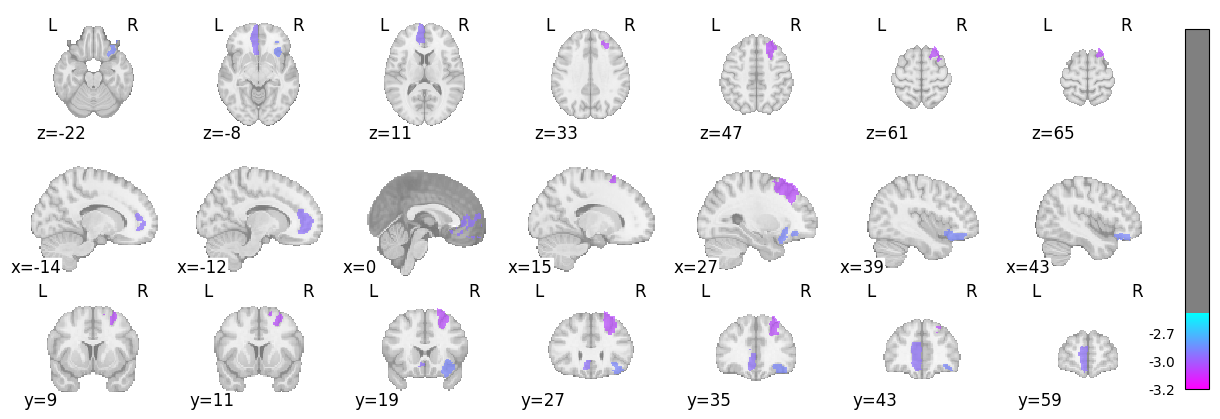

In [55]:
#create plots witt the t maps of the salience and default values in the brain
from templateflow.api import get
from nilearn.plotting import plot_roi, plot_anat    

cape = 'cape_PA_score'
seed = 'DRPutamen'

atlas_name = 'Schaefer2018'
desc_name = '100Parcels7Networks'

atlas_file = get('MNI152NLin2009cAsym',
resolution=2,
atlas= atlas_name,
desc= desc_name
)
# Load the atlas using nibabel
atlas = nib.load(atlas_file)

# Step 1: create zero image
masks = np.zeros(np.shape(atlas), dtype=np.float32)

# Step 2: Use the affine matrix from the atlas
affine = atlas.affine

atlas_data = atlas.get_fdata()  # Use get_fdata() instead of get_data()

for roi_id in rois_pa:

    # Step 3: Find the indices where the atlas has the ROI ID
    ix = np.where(atlas_data == roi_id)  # ROI ID in atlas

    t_value = results[f'{cape}'][roi_id]['t_value']
    if isinstance(t_value, pd.Series):  # If it's a Series, extract the first value
        t_value = t_value.iloc[0]
    t_value = float(t_value)  # Ensure it is a float

    # 4. Assign the t-value to the corresponding voxels in the mask
    masks[ix] = t_value

# Step 5: Create a NIfTI image using the modified zero_volume
tmap_affined = nib.Nifti1Image(masks, affine)

# Step 6: Plot the tmap in the brain
fig, ax = plt.subplots(figsize=(30/2.5, 10/2.5))  # Create a Matplotlib figure
display = plot_roi(
    tmap_affined,
    display_mode='mosaic',
    colorbar=True,
    vmin=-3.3,
    vmax=-2.5,
    cmap='cool_r',  # Color map for the t-map
    figure=fig  # Pass the Matplotlib figure
)

# Step 7: Customize the color bar
cbar = plt.gcf().get_axes()[-1]  # Get the color bar axis (last axis in the figure)
cbar.set_yticks([-3.3, -3, -2.7])  # Set custom tick values
cbar.set_yticklabels([ '-3.2', '-3.0', '-2.7'])  # Set custom tick labels

ax.spines['top'].set_visible(False)  # Hide the top spine
ax.spines['right'].set_visible(False)  # Hide the right spine
ax.spines['left'].set_visible(False)  # Hide the left spine
ax.spines['bottom'].set_visible(False)  # Hide the bottom spine
ax.xaxis.set_ticks([])  # Hide x-axis ticks
ax.yaxis.set_ticks([])  # Hide y-axis ticks

# Show the plot
plt.show()

# reading all the data to plot ajust the data to the model

In [2]:
#importing the data from the csv file in the folder second_level_results
os.environ["ROOTDIR"] = r'C:\Users\angel\Documents\INPD_neuroimages_CAPE'  # seth path

workdir = os.environ["ROOTDIR"]
secondlvresults  = os.path.join(workdir,"second_level_results")

shaeffer_network = pd.read_csv('tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv', delimiter='\t')
#extract the index with the name with SalVentAttn - salience network
salience_index = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn')]
#extract the index with the name with Default - default mode network
default_index = shaeffer_network[shaeffer_network['name'].str.contains('Default')]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]



#stat a dictionary to store the salience and default values
results_all = {}

for cape in ['cape_PA_score', 'cape_tot', 'cape_BE_score', 'cape_PI_score']:
    results_all[cape] = {}
    for seed in seednames:
        results_all[cape][seed] = {}
        for roi in salience_index['index']:
            results_all[cape][seed][roi] = pd.read_csv(os.path.join(secondlvresults,f'{cape}-{seed}-roi_{roi}_2ndlvl.csv'), index_col=0)
        for roi in default_index['index']:
            results_all[cape][seed][roi] = pd.read_csv(os.path.join(secondlvresults,f'{cape}-{seed}-roi_{roi}_2ndlvl.csv'), index_col=0)

[np.float64(0.0913361898034738), np.float64(0.0900419376727735), np.float64(0.0910824931730727), np.float64(0.0899732478389395), np.float64(0.0899397339698983), np.float64(0.0903077871943023), np.float64(0.0948368481673417), np.float64(0.0903102437550261), np.float64(0.0900672885460992), np.float64(0.0899625244390799), np.float64(0.0907023324825906), np.float64(0.0960826331778231), np.float64(0.0927876991693557), np.float64(0.0981399622953589), np.float64(0.0910799277464268), np.float64(0.0955133771417539), np.float64(0.0907577808619617), np.float64(0.0920797508963391), np.float64(0.0920740756106296), np.float64(0.0963748458175839), np.float64(0.0961221722681507), np.float64(0.0901742037933184), np.float64(0.093024114011417), np.float64(0.0939360912999692), np.float64(0.1077048571827475), np.float64(0.092469617255781), np.float64(0.0924506933434226), np.float64(0.0907131268444869), np.float64(0.0924003509830903), np.float64(0.0952015890199662), np.float64(0.0899544097508996), np.float6

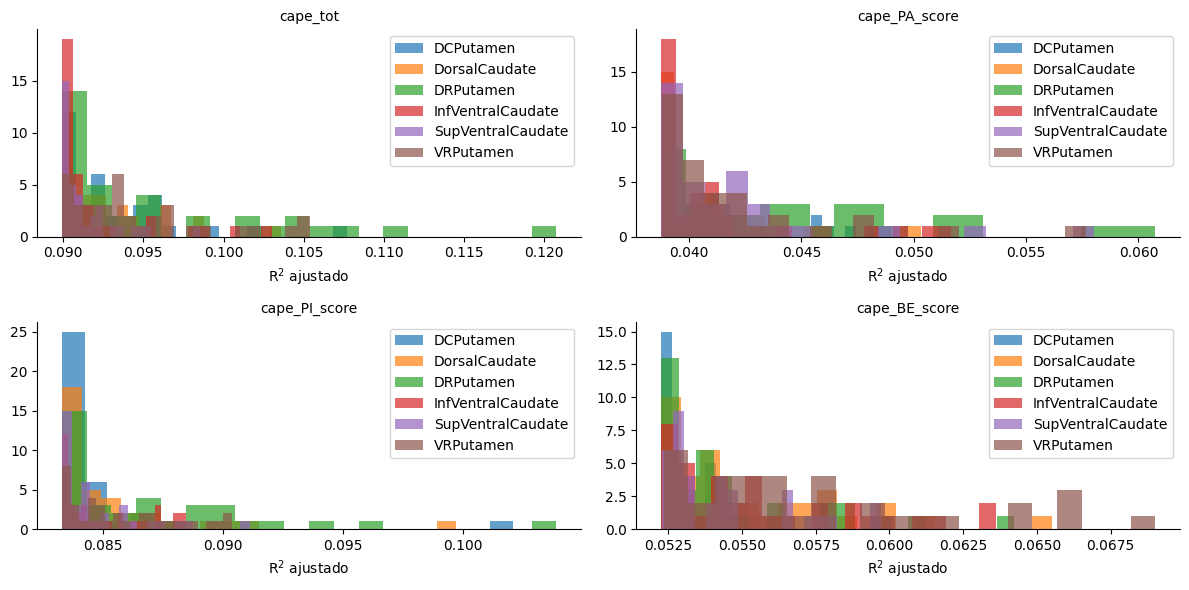

In [3]:
#make a histogram of R_squared values
plt.figure(figsize=(30/2.5 , 15/2.5))
# plt.title(f'R_squared values')
for idx, cape in enumerate(['cape_tot','cape_PA_score', 'cape_PI_score', 'cape_BE_score']):
    plt.subplot(2, 2, idx+1)
    plt.title(f'{cape}', fontsize=10)
    for seed in seednames:
        r_squared = []
        for roi in results_all[cape][seed].keys():
            r_squared.append(results_all[cape][seed][roi]['Adj_R_squared'].values[0])
        print(r_squared)

        plt.hist(
            r_squared, 
            bins=20,  
            alpha=0.7,
            label=f'{seed}')
        plt.legend()

    ax = plt.gca()  # Get the current axis
    ax.spines['top'].set_visible(False)  # Hide the top spine
    ax.spines['right'].set_visible(False)  # Hide the right spine
    plt.xlabel('R$^2$ ajustado')
    plt.tight_layout()


# Extra code may be removed

In [12]:
#I need to upload all the .csv files from supplementary_material/second_level_results and reorganize them into a single table. The first collumn have to be the file name and then the others keep as they are. I would like to stack one over another, they wolud have all the seae coloumns that they actually have but only with the new one regarding the name of the file. How to do it
import os
import pandas as pd
# Define the directory containing the CSV files
root_dir = os.getcwd()
directory = os.path.join(root_dir,'supplementary_materials\\second_level_results')
print(directory)

# Initialize an empty list to store DataFrames
dataframes = []
# Loop through all files in the directory
for filename in os.listdir(directory):
    # the files have to have cape in the name
    if 'cape' in filename:
        # Read each CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, filename))
        # Add a new column with the file name (without extension)
        df['file_name'] = os.path.splitext(filename)[0]
        # Append the DataFrame to the list
        dataframes.append(df)
# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes, ignore_index=True) 
# reorganize file_name as first column and drop unnamed column if exists
cols = combined_df.columns.tolist()
cols = [cols[-1]] + cols[:-1]
combined_df = combined_df[cols]
if 'Unnamed: 0' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Unnamed: 0'])
# Save the combined DataFrame to a new xlsx file

combined_df.to_excel(os.path.join(root_dir,'supplementary_materials\\second_level_results\\combined_second_level_results.xlsx'), 
                   index=False,
                   engine='openpyxl')

c:\Users\angel\Documents\masters-uploaded-github\INPD-neuroimage-cape\supplementary_materials\second_level_results


In [13]:
#I need to upload all the .csv files from supplementary_material\\sensitivity_analisys_second_level and reorganize them into a single table. The first collumn have to be the file name and then the others keep as they are. I would like to stack one over another, they wolud have all the seae coloumns that they actually have but only with the new one regarding the name of the file. How to do it
import os
import pandas as pd
# Define the directory containing the CSV files
root_dir = os.getcwd()
directory = os.path.join(root_dir,'supplementary_materials\\sensitivity_analisys_second_level')
print(directory)

# Initialize an empty list to store DataFrames
dataframes = []
# Loop through all files in the directory
for filename in os.listdir(directory):
    # the files have to have cape in the name
    if 'cl_p_fl' in filename:
        # Read each CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, filename))
        # Add a new column with the file name (without extension)
        df['file_name'] = os.path.splitext(filename)[0]
        # Append the DataFrame to the list
        dataframes.append(df)
# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes, ignore_index=True) 
# reorganize file_name as first column and drop unnamed column if exists
cols = combined_df.columns.tolist()
cols = [cols[-1]] + cols[:-1]
combined_df = combined_df[cols]
if 'Unnamed: 0' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Unnamed: 0'])
# Save the combined DataFrame to a new xlsx file

combined_df.to_excel(os.path.join(root_dir,'supplementary_materials\\sensitivity_analisys_second_level\\combined_sensitivity_analisys_second_level.xlsx'), 
                   index=False,
                   engine='openpyxl')

c:\Users\angel\Documents\masters-uploaded-github\INPD-neuroimage-cape\supplementary_materials\sensitivity_analisys_second_level
